In [1]:
# Plot light curve and phase diagram

import matplotlib.pyplot as plt
import numpy as np
from astropy.timeseries import LombScargle
# from scipy import stats
# from scipy.stats import distributions
# import similaritymeasures

In [2]:
#Choose data path

path = '/media/fernando/KINGSTON/Doutorado/2025/reduced/'
date = '20250706'
object = 'V2400Oph'
channel = '3'
source = '25'

data = f'{path}{date}/export_txt'

In [3]:
#   Reading polarimetry data

data1 = np.loadtxt(f'{data}/{object}_ch{channel}_SRC{source}_polar.txt',skiprows=1)

t1=data1[:,0]
mag1=data1[:,2]
mag1_error=data1[:,3]

In [4]:
# Removendo a media dos dados

mag_mean1=np.mean(mag1)
#mag_c1=mag1-mag_mean1
mag_c1=mag1

In [5]:
#data1 = np.loadtxt('11bocet_pol.txt',skiprows=0)

#t2=data1[:,0]
#mag2=data1[:,1]
#mag2_error=data1[:,2]

In [6]:
# Removendo a media dos dados
#
#mag_mean2=np.mean(mag2)
#mag_c2=mag2-mag_mean2
#mag_c2=mag2

In [7]:
#data1 = np.loadtxt('12bocet_pol.txt',skiprows=0)

#t3=data1[:,0]
#mag3=data1[:,1]
#mag3_error=data1[:,2]

In [8]:
# Removendo a media dos dados

#mag_mean3=np.mean(mag3)
#mag_c3=mag3-mag_mean3
#mag_c3=mag3

In [9]:
#data1 = np.loadtxt('19bocet_pol.txt',skiprows=0)

#t4=data1[:,0]
#mag4=data1[:,1]
#mag4_error=data1[:,2]

In [10]:
# Removendo a media dos dados
#
#mag_mean4=np.mean(mag4)
#mag_c4=mag4-mag_mean4
#mag_c4=mag4

In [11]:
time=t1
mag_c=mag_c1
mag_error=mag1_error
#time=np.concatenate((t1,t2,t3,t4))
#mag_c=np.concatenate((mag_c1,mag_c2,mag_c3,mag_c4))
#mag_error=np.concatenate((mag1_error,mag2_error,mag3_error,mag4_error))
# time=1.*t1
# mag_c=1.*mag_c1
# mag_error=1.*mag1_error

In [12]:
#  Filter data
#
filter="no"
# filter="yes"

In [13]:
##### Lomb Scargle
#
# limites em minutos
p1=10.
p2=20.
# 
p1=p1/60./24.0
p2=p2/60./24.0
# 
# limites em dias
# p1=0.
# p2=1.
#
#
# Numero de frequencias
#
n_freq=int(1e6)
frequency = np.linspace(1./p2, 1./p1, n_freq)

In [14]:
#  Fazendo o Lomb-Scargle
#
#ls = LombScargle(time, mag_c)
ls = LombScargle(time, mag_c,mag_error)
power = ls.power(frequency)
probabilities = [0.001]
fap=ls.false_alarm_level(probabilities) 
#
best_frequency = frequency[np.argmax(power)]
best_period=1./best_frequency
print(' ')
print('Best period in days  ', best_period)
print('Best period in hours  ', best_period*24.)
print('Best period in minutes  ', best_period*24.*60.)
print('False alarm probability of 0.001  ',fap)
print(' ')

 
Best period in days   0.010878645111262542
Best period in hours   0.261087482670301
Best period in minutes   15.665248960218062
False alarm probability of 0.001   [0.05307998]
 


In [15]:
best_period*60*24

15.66524896021806

In [16]:
927/60

15.45

In [17]:
((927.66/60)/60)/24

0.010736805555555555

In [18]:
#best_period=((927.66/60)/60)/24

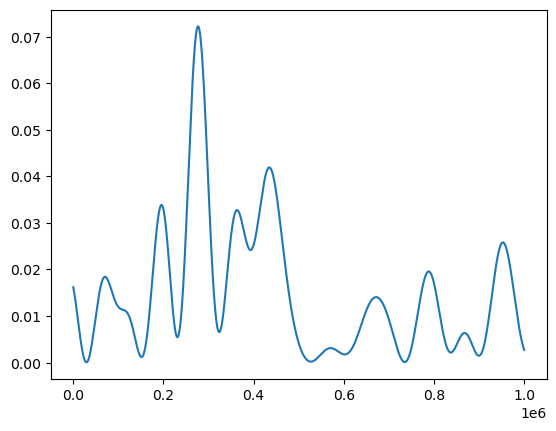

In [19]:
plt.plot(power)

In [20]:
# Calculando phase diagram
#
to=2460863.42808605
phase=((time-to)%best_period)/best_period

In [21]:
phase

array([0.13731399, 0.17204449, 0.20674666, 0.24146809, 0.27619105,
       0.31080025, 0.34546419, 0.38021425, 0.41493307, 0.44988526,
       0.48460934, 0.51929613, 0.5540117 , 0.5886916 , 0.62347681,
       0.65815988, 0.69302548, 0.72770111, 0.76237142, 0.79716939,
       0.83187112, 0.86657705, 0.90126492, 0.93586453, 0.9706205 ,
       0.00545942, 0.04027712, 0.07490485, 0.10956031, 0.14423384,
       0.17892274, 0.2137106 , 0.24855222, 0.28335772, 0.3179711 ,
       0.35265259, 0.38732236, 0.42201185, 0.45673593, 0.49144345,
       0.52616753, 0.56097033, 0.5956906 , 0.63035137, 0.66502965,
       0.69970797, 0.73449211, 0.76921619, 0.80396895, 0.83865682,
       0.87345324, 0.90813418, 0.94286455, 0.97758277, 0.01226909,
       0.04697023, 0.08160442, 0.11666307, 0.15139507, 0.18614196,
       0.22085432, 0.2554826 , 0.29032422, 0.32499133, 0.35991702,
       0.39469585, 0.42938744, 0.46410934, 0.49883715, 0.53365056,
       0.56836018, 0.60306996, 0.63775029, 0.67265202, 0.70729

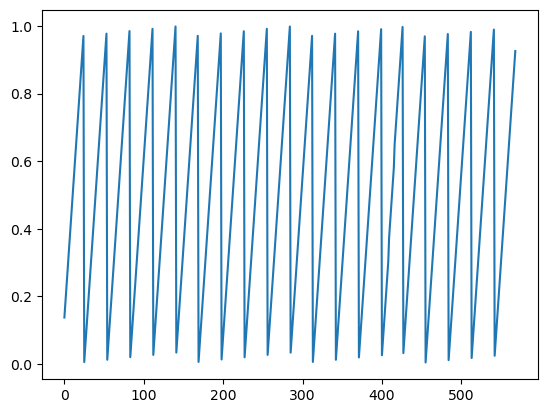

In [22]:
plt.plot(phase)

In [23]:
# Binning data in the best period
#
number_bins=6
center_bin=np.zeros(number_bins)
bin_means=np.zeros(number_bins)
bin_size=1./number_bins
bins = np.linspace(0, 1, number_bins+1)
digitized = np.digitize(phase, bins)
# print(bins)
# print(digitized)

In [24]:
number_bins

6

In [25]:
center_bin

array([0., 0., 0., 0., 0., 0.])

In [26]:
bin_means

array([0., 0., 0., 0., 0., 0.])

In [27]:
bin_size

0.16666666666666666

In [28]:
bins

array([0.        , 0.16666667, 0.33333333, 0.5       , 0.66666667,
       0.83333333, 1.        ])

In [29]:
digitized

array([1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6,
       6, 6, 6, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4,
       4, 5, 5, 5, 5, 6, 6, 6, 6, 6, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3,
       3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 1, 1, 1, 1, 1,
       2, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6,
       6, 6, 1, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5,
       5, 5, 5, 5, 6, 6, 6, 6, 6, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3,
       3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 6, 6, 6, 6, 6,
       1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5,
       5, 5, 6, 6, 6, 6, 6, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 4,
       4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 1, 1, 1, 1, 1, 2, 2, 2,
       2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 1,
       1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4,

In [30]:
for i in range(1, len(bins)):
    im=i-1
    center_bin[im]=bins[i]-0.5*bin_size
    bin_means[im]=np.mean(mag_c[digitized == i])
    print(i,center_bin[im],bin_means[im]) 
#
#    Model sinuosoidal
# 
y_fit = ls.model(time, best_frequency)

1 0.08333333333333333 -9.196818956125805
2 0.25 -9.177637824682291
3 0.4166666666666667 -9.143549966432634
4 0.5833333333333333 -9.126931139866317
5 0.7499999999999999 -9.150514818267707
6 0.9166666666666666 -9.18436255062766


In [31]:
mag_c

array([-9.15664518, -9.16554715, -9.16258641, -9.16083748, -9.15523688,
       -9.14672112, -9.14052037, -9.13767562, -9.12276305, -9.10631121,
       -9.09214175, -9.07552646, -9.05953893, -9.04950264, -9.04175041,
       -9.03065677, -9.02997458, -9.03895849, -9.0550629 , -9.08362808,
       -9.11706096, -9.13728341, -9.15250428, -9.16904342, -9.17830034,
       -9.18411185, -9.1865079 , -9.1748348 , -9.15956363, -9.15138016,
       -9.13417504, -9.1112447 , -9.09184114, -9.06799836, -9.03574929,
       -9.00616195, -8.97597169, -8.94532297, -8.92075865, -8.90338923,
       -8.89907731, -8.90506956, -8.91527986, -8.93807901, -8.96346426,
       -8.98509204, -9.01411009, -9.03697697, -9.04933395, -9.05541733,
       -9.05704305, -9.05505619, -9.05091308, -9.05379148, -9.06400095,
       -9.08227576, -9.1019494 , -9.12889304, -9.16949162, -9.2027749 ,
       -9.23011405, -9.24074947, -9.24262238, -9.23317681, -9.21643037,
       -9.20767202, -9.17124202, -9.13527114, -9.11010269, -9.10

In [32]:
len(mag_c)

569

In [33]:
mag_c[digitized==1]

array([-9.15664518, -9.18411185, -9.1865079 , -9.1748348 , -9.15956363,
       -9.15138016, -9.06400095, -9.08227576, -9.1019494 , -9.12889304,
       -9.16949162, -9.31840236, -9.31134401, -9.29226733, -9.2725562 ,
       -9.2599089 , -9.22763459, -9.20768143, -9.19775055, -9.19300489,
       -9.19998759, -9.34139824, -9.34793137, -9.34459071, -9.32530451,
       -9.1932437 , -9.18420755, -9.16726578, -9.15743244, -9.15259743,
       -9.00123783, -9.00971695, -9.01560981, -9.03141949, -9.04656736,
       -9.23285183, -9.2522931 , -9.26436088, -9.27443158, -9.28766739,
       -9.18677041, -9.18329004, -9.16824439, -9.15957985, -9.15737023,
       -9.1338652 , -9.15498707, -9.16770398, -9.17587168, -9.18531656,
       -9.18847152, -9.18530419, -9.18951817, -9.18653039, -9.17136934,
       -9.1921587 , -9.20444355, -9.21248895, -9.22448679, -9.20086181,
       -9.17413098, -9.14742153, -9.12921693, -9.12245701, -9.10244048,
       -9.10043932, -9.09101661, -9.08215597, -9.0738318 , -9.25

In [34]:
bin_means

array([-9.19681896, -9.17763782, -9.14354997, -9.12693114, -9.15051482,
       -9.18436255])

In [35]:
y_fit

array([-9.20504748, -9.20086485, -9.19552754, -9.18928176, -9.18242594,
       -9.17530887, -9.16823317, -9.16152842, -9.15553575, -9.15050326,
       -9.14673594, -9.14437776, -9.1435355 , -9.14425009, -9.1464951 ,
       -9.15015121, -9.15507856, -9.16099132, -9.16763249, -9.17471537,
       -9.1818598 , -9.18874743, -9.19504812, -9.20045496, -9.20474679,
       -9.20769839, -9.20915677, -9.20905947, -9.20742126, -9.20431698,
       -9.19989162, -9.1943385 , -9.18792229, -9.18096443, -9.17382965,
       -9.16680345, -9.16023418, -9.15442692, -9.14965617, -9.14615573,
       -9.1440882 , -9.14355419, -9.1445812 , -9.14711188, -9.1510294 ,
       -9.1561476 , -9.16224417, -9.16900309, -9.17611958, -9.18323723,
       -9.19005272, -9.19620009, -9.20141859, -9.20545021, -9.20810412,
       -9.20925919, -9.20886157, -9.2069009 , -9.2035055 , -9.19882304,
       -9.19308315, -9.18657026, -9.17953487, -9.17238657, -9.16537854,
       -9.15892578, -9.15331789, -9.1487999 , -9.14559086, -9.14

In [36]:
len(y_fit)

569

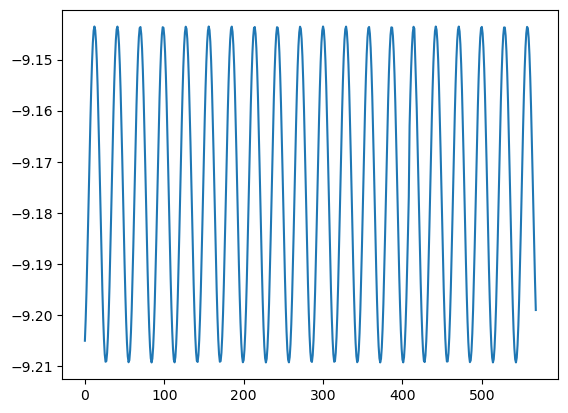

In [37]:
plt.plot(y_fit)

In [38]:
# Filtrando
#
if (filter != "no"):
	f= open("bocet_fot_p1_509.txt","x")
	mag_filtered=np.zeros(len(mag_c))
	for i in range(0, len(mag_c)):
#
#    Aqui eu filtro por media do bin - nao eh bom
#
# 		mag_filtered[i]=mag[i]-bin_means[digitized[i]-1]
#  
#    Aqui filtro por Model sinuosoidal
# 
		mag_filtered[i]=mag_c[i]-y_fit[i]
		f.write(f"{time[i]} {mag_c[i]} {mag_filtered[i]} \n")
	
#
	f.close()

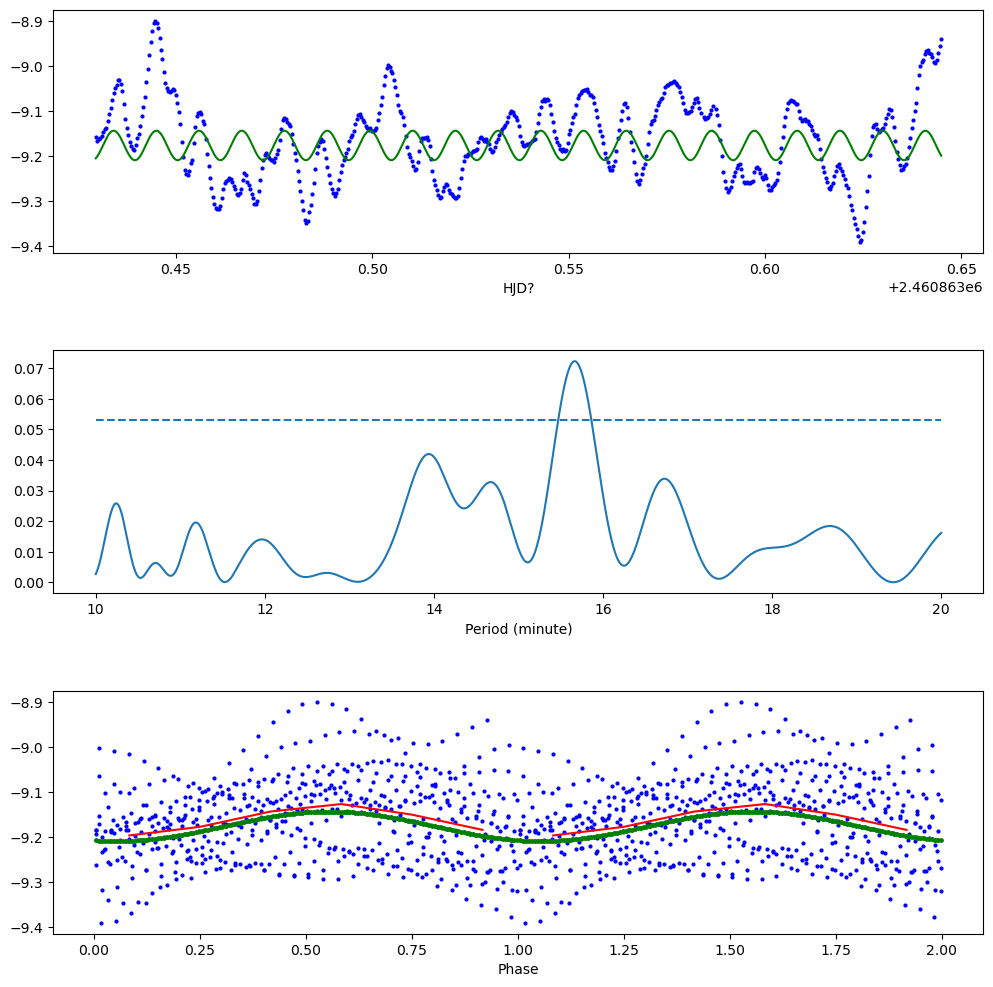

In [39]:
#### Plot

plt.close('all')

#f, ax = plt.subplots(2, sharex=True)
f, ax = plt.subplots(3, figsize=(12, 12), sharex=False)
f.subplots_adjust(hspace=0.4)
#f.align_ylabels(ax[0:1])

ax[0].plot(time,mag_c,'b.',markersize=4)
ax[0].plot(time,y_fit,'g-',markersize=4)
ax[0].set_xlabel('HJD?')
# ax[0].set_xlim(52455.2,52455.4)

ax[1].plot(1./frequency*24.*60.,power)
ax[1].set_xlabel('Period (minute)')
xmin=p1*24.*60.
xmax=p2*24.*60.
# ax[1].plot(1./frequency,power)
# ax[1].set_xlabel('Period (d)')
# xmin=p1
# xmax=p2
ax[1].hlines(fap,xmin,xmax,linestyles='dashed')

ax[2].plot(phase,mag_c,'b.',markersize=4)
ax[2].plot(phase+1.0,mag_c,'b.',markersize=4)
ax[2].plot(phase,y_fit,'g.',markersize=4)
ax[2].plot(phase+1.0,y_fit,'g.',markersize=4)
ax[2].plot(center_bin,bin_means,'r-',markersize=4)
ax[2].plot(center_bin+1.0,bin_means,'r-',markersize=4)
ax[2].set_xlabel('Phase')
# ax[2].set_xlim(0,2)
#ax[2].plot(t_fit,y_fit,'k-')

# print(time.size)
# print(time_b.size)
# print(time_v.size)
plt.show()